# 5. Dynamic Modeling
The derived matrices and vectors are:

$$
A = \begin{array}{c|rrrrrrrrrr}
     & \theta_0 & \theta_1 & \theta_2 & \theta_3 & \theta_4 & \theta_5 & \theta_6 & \theta_7 & \theta_8 & \theta_9 \\
\hline
q_0   &  1 &  0 &  0 &  0 &  0 &  0 &  0 &  0 &  0 &  0 \\
q_1   & -1 &  1 &  0 &  0 &  0 &  0 &  0 &  0 &  0 &  0 \\
q_2   &  0 & -1 &  1 &  0 &  0 &  0 &  0 &  0 &  0 &  0 \\
q_3   &  0 &  0 & -1 &  1 &  0 &  0 &  0 &  0 &  0 &  0 \\
q_4   &  0 &  0 &  0 & -1 &  1 &  0 &  0 &  0 &  0 &  0 \\
q_5   &  0 &  0 &  0 &  0 & -1 &  1 &  0 &  0 &  0 &  0 \\
q_6   &  0 &  0 &  0 &  0 &  0 &  1 & -1 &  0 &  0 &  0 \\
q_7   &  0 &  0 &  0 &  0 &  0 &  0 &  1 & -1 &  0 &  0 \\
q_8   &  0 &  0 &  0 &  0 &  0 &  0 &  0 &  1 &  0 &  0 \\
q_9   &  0 &  0 &  0 &  0 &  0 &  0 &  0 &  0 &  1 &  0 \\
q_{10} & 0 &  0 &  0 &  0 &  0 &  0 &  0 &  0 & -1 &  1 \\
q_{11} & 0 &  0 &  0 &  0 &  0 &  1 &  0 &  0 &  0 & -1 \\
q_{12} & 0 &  0 &  0 &  0 &  0 &  1 &  0 &  0 &  0 &  0 \\
q_{13} & 0 &  0 &  0 &  0 &  0 &  1 &  0 &  0 &  0 &  0 \\
\end{array}
$$

$$G = \mathrm{diag}(667.5,\; 233.63,\; 233.63,\; 18.02,\; 18.02,\; 213.6,\; 28.8,\; 126,\; 90,\; 67.5,\; 15.43,\; 15.43,\; 30,\; 0)$$

$$C = \mathrm{diag}(0,\; 17{,}293{,}120,\; 0,\; 142{,}152,\; 0,\; 108{,}000,\; 0,\; 435{,}600,\; 101{,}507,\; 0)$$

$$b = (T_o\; 0\; 0\; 0\; 0\; 0\; 0\; 0\; T_o\; T_o\; 0\; 0\; T_o\; T_i)^T$$

$$f = (667.5\; 0\; 0\; 0\; 54\; 0\; 0\; 273.6\; 135\; 0)^T$$

$$y = (0\; 0\; 0\; 0\; 0\; 1\; 0\; 0\; 0\; 0)^T$$

These matrices are then input into the `.csv` file as follows, to utilise the sample code from [1]:

<!-- Figure: csv.png — Matrices input in .csv -->

In [16]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import dm4bem
csv = pd.read_csv("TCgen.csv")
csv


controller = False
neglect_air_glass_capacity = False
imposed_time_step = False
Δt = 498    # s, imposed time step
Tout = 10
Tin = 20
df = pd.read_csv('TCgen.csv')
df.style.apply(lambda x: ['background-color: yellow'
                          if x.name in df.index[-3:] or c in df.columns[-2:]
                          else '' for c in df.columns], axis=1)

# MODEL
# =====
# Thermal circuit
TC = dm4bem.file2TC('TCgen.csv', name='', auto_number=False)

if controller:
    TC['G']['q13'] = 1e3        # Kp -> ∞, almost perfect controller



# 6. Steady-State Analysis

Consider the following boundary conditions as a falsification test:
- Outdoor temperature: $T_o = 10\ °\text{C}$ (applied to branches $q_0$, $q_8$, $q_9$, $q_{12}$),
- Indoor setpoint temperature: $T_i = 20\ °\text{C}$ (on branch $q_{13}$),
- All flow-rate sources: $f_{ss} = 0$.

## 6.1 Steady-State from Differential Algebraic Equations

The dynamic behavior of the thermal circuit is described by the following system of differential-algebraic equations [1]:

$$
\left\{
\begin{aligned}
    C\dot{\theta} &= -(A^T G A)\,\theta + A^T G\,b + f \\
    q &= G(-A\theta + b)
\end{aligned}
\right.
$$

where:
- $\theta \in \mathbb{R}^n$ is the vector of node temperatures (°C),
- $q \in \mathbb{R}^m$ is the vector of branch heat fluxes (W),
- $A \in \mathbb{R}^{m \times n}$ is the **incidence matrix** of the thermal network, with entries $+1$, $-1$, or $0$ depending on branch orientation with respect to nodes,
- $G = \mathrm{diag}(G_0, G_1, \ldots, G_{m-1}) \in \mathbb{R}^{m \times m}$ is the diagonal matrix of **branch conductances** (W/K),
- $C = \mathrm{diag}(C_0, C_1, \ldots, C_{n-1}) \in \mathbb{R}^{n \times n}$ is the diagonal matrix of **nodal thermal capacitances** (J/K),
- $b \in \mathbb{R}^m$ is the vector of **temperature sources** on branches (°C),
- $f \in \mathbb{R}^n$ is the vector of **flow-rate sources** (heat injected) at nodes (W),
- $\dot{\theta} = d\theta/dt$ is the time derivative of node temperatures.

<!-- Figure: code1.png — Steady-state node temperatures when the flow sources are zero (code) -->

<!-- Figure: FirstSections/1.png — Steady-state node temperatures when the flow sources are zero (result) -->

<!-- Figure: code2.png — Steady-state node temperatures when the flow sources are not zero (code) -->

<!-- Figure: FirstSections/2.png — Steady-state node temperatures when the flow sources are not zero (result) -->

## 6.2 Steady-State from State-Space Representation

Since not all nodes necessarily have a capacitance associated with them, the DAE system can be reduced to a state-space representation. Only nodes with non-zero capacitances appear as state variables $\theta_i$. The state-space form is:

$$
\left\{
\begin{aligned}
    \dot{\theta}_s &= A_s\,\theta_s + B_s\,u \\
    y &= C_s\,\theta_s + D_s\,u
\end{aligned}
\right.
$$

where:
- $\theta_s \in \mathbb{R}^{n_s}$ is the **state vector** of temperatures at nodes with non-zero thermal capacitance (the "thermal masses") (°C),
- $u \in \mathbb{R}^p$ is the **input vector**, which stacks the non-zero temperature sources $b_T$ and flow-rate sources $f_Q$:
$$u = \begin{bmatrix} b_T \\ f_Q \end{bmatrix}$$
- $y \in \mathbb{R}^q$ is the **output vector** (e.g., the indoor air temperature),
- $A_s \in \mathbb{R}^{n_s \times n_s}$ is the **state matrix**,
- $B_s \in \mathbb{R}^{n_s \times p}$ is the **input matrix**,
- $C_s \in \mathbb{R}^{q \times n_s}$ is the **output matrix**,
- $D_s \in \mathbb{R}^{q \times p}$ is the **feedthrough (direct) matrix**.

<!-- Figure: FirstSections/AsBsCsDs.png — State matrices -->

<!-- Figure: code3.png — Steady state input and output vector when all flow sources are zero (code) -->

<!-- Figure: FirstSections/3.png — Steady state input and output vector when all flow sources are zero (result) -->

<!-- Figure: code4.png — Steady state input and output vector when all flow sources are not zero (code) -->

<!-- Figure: FirstSections/4.png — Steady state input and output vector when all flow sources are not zero (result) -->

In [17]:

# State-space
[As, Bs, Cs, Ds, us] = dm4bem.tc2ss(TC)

# DAE steady-state: To=10°C, Ti=20°C, nominal constant flow sources
# b vector has 14 entries (q0–q13):
#   To  at q0, q8, q9, q12  -> indices 0, 8, 9, 12
#   Ti  at q13               -> index 13
bss = np.zeros(14)
bss[[0, 8, 9, 12]] = Tout    # outdoor temperature
bss[[13]] = Tin             # indoor set-point temperature

fss = np.zeros(10)

A = TC['A']
G = TC['G']
diag_G = pd.DataFrame(np.diag(G), index=G.index, columns=G.index)

θss = np.linalg.inv(A.T @ diag_G @ A) @ (A.T @ diag_G @ bss + fss)
print(f'θss = {np.around(θss, 2)} °C')
print('=================================================')

# DAE steady-state with zero temperatures, only heat flow sources
bss_Q = np.zeros(14)

fss_Q = np.zeros(10)
fss_Q[0] = 667.5
fss_Q[4] = 54.0
fss_Q[7] = 273.6
fss_Q[8] = 135.0

θssQ = np.linalg.inv(A.T @ diag_G @ A) @ (A.T @ diag_G @ bss_Q + fss_Q)
print(f'θssQ = {np.around(θssQ, 2)} °C')
print('=================================================')
# State-space steady-state
# us has 9 entries: [To, To, To, To, Ti, 667.5, 54.0, 273.6, 135.0]
bT = np.array([Tout, Tout, Tout, Tout, Tin])        # [To, To, To, To, Ti]
fQ = np.array([0, 0, 0, 0]) # constant flow sources at nominal values
uss = np.hstack([bT, fQ])
print(f'uss = {uss}')

inv_As = pd.DataFrame(np.linalg.inv(As),
                      columns=As.index, index=As.index)

print(f'As = {inv_As.shape}')
print(f'As = {inv_As}')
print(f'Bs = {Bs}')
print(f'Bs = {Bs.shape}')
print(f'Cs = {Cs}')
print(f'Ds = {Ds}')
yss = (-Cs @ inv_As @ Bs + Ds) @ uss

yss = float(yss.values[0])
print(f'yss = {yss:.2f} °C')

print(f'Error between DAE and state-space: {abs(θss[5] - yss):.2e} °C')
print('=================================================')
# State-space: zero temperatures, same nominal constant flows
bT_Q = np.array([0, 0, 0, 0, 0])
fQ_Q = np.array([667.5, 54.0, 273.6, 135.0])
uss_Q = np.hstack([bT_Q, fQ_Q])

inv_As = pd.DataFrame(np.linalg.inv(As),
                      columns=As.index, index=As.index)
yssQ = (-Cs @ inv_As @ Bs + Ds) @ uss_Q

yssQ = float(yssQ.values[0])
print(f'uss = {uss_Q}')
print(f'yssQ = {yssQ:.2f} °C')

print(f'Error between DAE and state-space: {abs(θssQ[5] - yssQ):.2e} °C')
print('=================================================')

θss = [10. 10. 10. 10. 10. 10. 10. 10. 10. 10.] °C
θssQ = [1.02 1.06 1.1  1.68 2.26 2.05 2.69 2.84 2.01 2.03] °C
uss = [10 10 10 10 20  0  0  0  0]
As = (5, 5)
As =               θ1           θ3           θ5           θ7           θ8
θ1 -95909.450518  -446.804726   -78.197970   -65.174593    -7.538747
θ3 -54354.829583 -5068.738597  -887.110288  -739.367689   -85.522684
θ5 -12521.174807 -1167.634275 -1701.454347 -1418.087903  -164.030273
θ7  -2587.401436  -241.282359  -351.592042 -4132.889013   -33.895555
θ8  -1284.329770  -119.767313  -174.522639  -145.456999 -1366.382950
Bs =          q0        q8        q9       q12  q13            θ0            θ4  \
θ1  0.00001  0.000000  0.000000  0.000000  0.0  1.499228e-08  0.000000e+00   
θ3  0.00000  0.000000  0.000000  0.000000  0.0  0.000000e+00  5.473004e-07   
θ5  0.00000  0.000000  0.000000  0.000278  0.0  0.000000e+00  8.538890e-06   
θ7  0.00000  0.000207  0.000000  0.000000  0.0  0.000000e+00  0.000000e+00   
θ8  0.00000  0.000000  0.0

# 7. Eigenvalues Analysis

<!-- Figure: FirstSections/5.png — System eigenvalues -->

## 7.1 Time Step

The maximum stable time step for the Euler explicit integration method is determined by the most negative eigenvalue $\lambda_{\min}$ of the state matrix $A_s$:

$$\Delta t_{\max} = \frac{-2}{\lambda_{\min}}$$

For this system, the computed value is:

$$\Delta t_{\max} = 2406\ \text{s} = 40.1\ \text{min}$$

To ensure the time step aligns with the weather data resolution, $\Delta t$ is rounded down to the nearest value that divides evenly into the data period:

$$\Delta t = 1800\ \text{s} = 30.0\ \text{min}$$

This value is safely below $\Delta t_{\max}$, guaranteeing numerical stability. Using a time step equal to the weather data resolution also avoids unnecessary interpolation error in the input signals.

<!-- Figure: FirstSections/6.png — Time step of the system -->

In [18]:
# Eigenvalues analysis
λ = np.linalg.eig(As)[0]        # eigenvalues of matrix As
print(f'λ = {λ}')
print('=================================================')

λ = [-8.31053087e-04 -6.86907311e-04 -1.03961171e-05 -1.86199345e-04
 -2.52558708e-04]


## 7.2 Settling Time and Duration

The settling time is the time required for the system to move on from the transient state to reach a quasi-steady response driven by the weather inputs. It is estimated as four times the largest time constant $T_{\max}$ of the system:

$$t_{\text{settle}} \approx 4 \cdot T_{\max} = 384{,}759\ \text{s} = 106.9\ \text{h}$$

The simulation duration is then rounded up to the nearest multiple of $\Delta t$ that is greater than or equal to $t_{\text{settle}}$:

$$t_{\text{duration}} = 385{,}200\ \text{s} = 107.0\ \text{h}$$

<!-- Figure: FirstSections/7.png — Settling time and duration of the system -->

In [19]:
# time step
Δtmax = 2 * min(-1. / λ)    # max time step for stability of Euler explicit
dm4bem.print_rounded_time('Δtmax', Δtmax)

if imposed_time_step:
    dt = Δt
else:
    dt = dm4bem.round_time(Δtmax)

dm4bem.print_rounded_time('dt', dt)
print(f"dt = {dt:.0f} s")

if dt < 10:
    raise ValueError("Time step is too small. Stopping the script.")
print('=================================================')
# settling time
t_settle = 4 * max(-1 / λ)
dm4bem.print_rounded_time('t_settle', t_settle)

# duration: next multiple of 3600 s that is larger than t_settle
duration = np.ceil(t_settle / 3600) * 3600
dm4bem.print_rounded_time('duration', duration)

Δtmax = 2406 s = 40.1 min
dt = 1800 s = 30.0 min
dt = 1800 s
t_settle = 384759 s = 106.9 h
duration = 385200 s = 107.0 h


# 8. Step Response to Outdoor Temperature

<!-- Figure: exim.png — Step response to outdoor temperature using Euler implicit and explicit integration -->

<!-- Figure: FirstSections/8.png — Step response summary -->

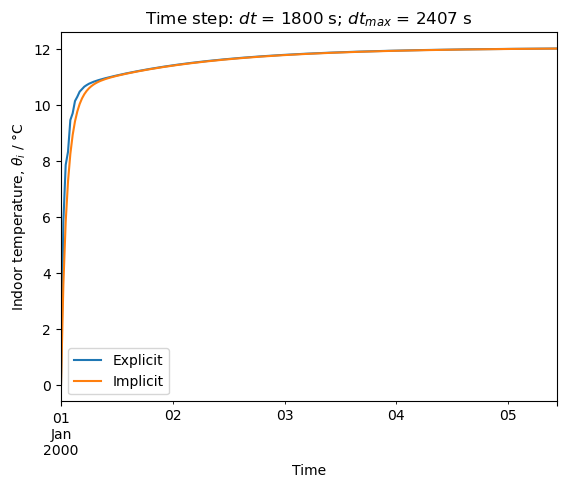

Steady-state indoor temperature obtained with:
- DAE model: 10.0000 °C
- state-space model: 10.0000 °C
- steady-state response to step input: 12.0253 °C


In [20]:
# Create input_data_set
# ---------------------
# time vector
n = int(np.floor(duration / dt))    # number of time steps

# DateTimeIndex starting at "00:00:00" with a time step of dt
time = pd.date_range(start="2000-01-01 00:00:00",
                     periods=n, freq=f"{int(dt)}s")

To = 10 * np.ones(n)        # outdoor temperature
Ti = 20 * np.ones(n)        # indoor temperature set point

# Constant heat flow sources (numeric column names matching us values)
f667 = 667.5 * np.ones(n)   # heat source at θ0
f54  = 54.0  * np.ones(n)   # heat source at θ4
f274 = 273.6 * np.ones(n)   # heat source at θ7
f135 = 135.0 * np.ones(n)   # heat source at θ8

data = {'To': To, 'Ti': Ti,
        667.5: f667, 54.0: f54, 273.6: f274, 135.0: f135}
input_data_set = pd.DataFrame(data, index=time)

# inputs in time from input_data_set
u = dm4bem.inputs_in_time(us, input_data_set)

# Initial conditions
θ_exp = pd.DataFrame(index=u.index)     # empty df with index for explicit Euler
θ_imp = pd.DataFrame(index=u.index)     # empty df with index for implicit Euler

θ0 = 0.0                    # initial temperatures
θ_exp[As.columns] = θ0      # fill θ for Euler explicit with initial values θ0
θ_imp[As.columns] = θ0      # fill θ for Euler implicit with initial values θ0

I = np.eye(As.shape[0])     # identity matrix
for k in range(u.shape[0] - 1):
    θ_exp.iloc[k + 1] = (I + dt * As)\
        @ θ_exp.iloc[k] + dt * Bs @ u.iloc[k]
    θ_imp.iloc[k + 1] = np.linalg.inv(I - dt * As)\
        @ (θ_imp.iloc[k] + dt * Bs @ u.iloc[k])

# outputs
y_exp = (Cs @ θ_exp.T + Ds @ u.T).T
y_imp = (Cs @ θ_imp.T + Ds @ u.T).T

# plot results
y = pd.concat([y_exp, y_imp], axis=1, keys=['Explicit', 'Implicit'])
# Flatten the two-level column labels into a single level
y.columns = y.columns.get_level_values(0)

ax = y.plot()
ax.set_xlabel('Time')
ax.set_ylabel('Indoor temperature, $\\theta_i$ / °C')
ax.set_title(f'Time step: $dt$ = {dt:.0f} s; $dt_{{max}}$ = {Δtmax:.0f} s')
plt.show()
print('=================================================')
print('Steady-state indoor temperature obtained with:')
print(f'- DAE model: {float(θss[5]):.4f} °C')
print(f'- state-space model: {float(yss):.4f} °C')
print(f'- steady-state response to step input: \
{y_exp["θ5"].tail(1).values[0]:.4f} °C')